# DRIVE


In [ ]:
#Your google drive is made accesible to Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive/')
    #%cd /content/drive/MyDrive/tfg_guillermo/code/Transporte lineal 2 (sin model.fit).ipynb
    %cd /content/drive/MyDrive/TFGs_TFM_2023-2024/TFGs_propuestas_Física/Guillermo_Gracia_Rebullida/tfg_guillermo/code
    %ls -lht
    # To import own packages set local path in packages syspath
    import sys
    sys.path.insert(0,"./")
except ImportError:
    print("You are not in google.colab!!")
    import os
    # List files in the current working directory
    files_in_directory = os.listdir()
    for file in files_in_directory:
        print(file)

Mounted at /content/drive/
/content/drive/MyDrive/TFGs_TFM_2023-2024/TFGs_propuestas_Física/Guillermo_Gracia_Rebullida/tfg_guillermo/code
total 1.7M
-rw------- 1 root root 404K May 10 10:49 'Ecuación burgers no viscosa.ipynb'
-rw------- 1 root root 377K May  8 21:07 'Copia de Ecuación burgers no viscosa.ipynb'
-rw------- 1 root root  22K May  8 19:40 'Burgers(model.fit).ipynb'
-rw------- 1 root root  92K Apr 14 17:30 'Transporte lineal 2 (sin model.fit).ipynb'
-rw------- 1 root root  23K Apr 10 16:21 'Ecuación burgers.ipynb'
-rw------- 1 root root  22K Apr 10 15:51  advecciondif.ipynb
-rw------- 1 root root 567K Mar 23 12:33  escalon.gif
-rw------- 1 root root 104K Mar 20 11:58 'Transporte lineal 2 (model.fit).ipynb'
-rw------- 1 root root  15K Mar 20 11:49 'Transporte lineal (sin model.fit).ipynb'
-rw------- 1 root root  43K Mar 11 16:18 'Transporte lineal (model.fit).ipynb'
-rw------- 1 root root 4.2K Feb 15 10:57 'Transporte lineal (sin model.fit).py'
-rw------- 1 root root 4.8K 

# Librerias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sympy.utilities.lambdify import lambdify
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense
import imageio.v2 as imageio

# Condiciones iniciales

In [ ]:
#condiciones iniciales

def u0(x):
  return np.where((x > 0) & (x < 1), 1.0, 0)
  #return np.where((x >= 0.1) & (x <= 0.3), 1.0, 0.0)

#ecuación

#du\dt+u*du\dx=0

# Datos

In [ ]:
#dominio

xmin=0
xmax=2
tmin=0
tmax=2
n_train=150
n_train0=175
n_border=75
N_STEPS=10000
log_each=500



# Entrenamiento PINN

In [ ]:
#parametros redes
nInput=2
nOutput=1
nhiddenlayers=6
nnhiddenlayers=125

#hiperparametros
lr=0.001

#nn

model=Sequential()
model.add(Input(shape=(nInput,)))
for i in range(0,nhiddenlayers):
  model.add(Dense(nnhiddenlayers,activation='sigmoid'))
model.add(Dense(1,activation=None))

# Metrica, perdida y optimizador
loss = tf.keras.losses.MeanSquaredError()
metrics = tf.keras.metrics.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam(lr)

model.compile(loss=loss,optimizer=optimizer,metrics=[metrics])

ceros = tf.zeros(n_border,dtype=tf.float32)
ones = tf.ones(n_border,dtype=tf.float32)
twos =2*ones

x_train=np.random.uniform(xmin,xmax,n_train)
t_train=np.random.uniform(tmin,tmax,n_train)
tensor_train=np.column_stack((x_train,t_train))
tensor_train=tf.convert_to_tensor(tensor_train,dtype=tf.float32)

x_train0=np.random.uniform(xmin,xmax,size=n_train0)
t_train0=np.zeros(n_train0)
tensor_train0=np.column_stack((x_train0,t_train0))
tensor_train0=tf.convert_to_tensor(tensor_train0,dtype=tf.float32)

t = tf.convert_to_tensor(np.random.uniform(tmin,tmax,n_border),dtype=tf.float32)
tensor_border1 = tf.stack([ceros,t], axis=-1)
tensor_border2 = tf.stack([twos,t], axis=-1)

u00 = tf.expand_dims(u0(x_train0),axis=1)
tensor0=tf.expand_dims(tf.zeros(n_border,dtype=tf.float32),axis=1)

#@tf.function
def model_fit(N_STEPS):
    history = {'loss': [0.0], 'PL': [0.0], 'ZL': [0.0], 'BL': [0.0]}
    for step in range(0,N_STEPS+1):
      with tf.GradientTape(persistent=True) as tape:
          tape.watch(tensor_train)
          with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(tensor_train)
            tape2.watch(tensor_train0)
            tape2.watch(tensor_border1)
            tape2.watch(tensor_border2)

            uNN = model(tensor_train,training=True)
            uNN0 = model(tensor_train0,training=True)
            uNNborder1 = model(tensor_border1,training=True)
            uNNborder2 = model(tensor_border2,training=True)

          partial_derivatives = tape2.gradient(uNN,tensor_train)

          partial_loss = model.compiled_loss(partial_derivatives[:,1],-uNN*partial_derivatives[:,0])
          zero_loss = model.compiled_loss(uNN0, u00)
          #border_loss = model.compiled_loss(uNNborder1,tensor0)+model.compiled_loss(uNNborder2,tensor0)
          border_loss = model.compiled_loss(uNNborder1,uNNborder2)
          loss=tf.cast(partial_loss, dtype=tf.float32)+tf.cast(zero_loss, dtype=tf.float32)+tf.cast(border_loss, dtype=tf.float32)

      gradients=tape.gradient(loss,model.trainable_weights)
      model.optimizer.apply_gradients(zip(gradients, model.trainable_weights))

      if step % log_each == 0:
          metrics= {m.name: m.result() for m in model.metrics}
          metrics['PL']= partial_loss.numpy()
          metrics['ZL']=zero_loss.numpy()
          metrics['BL']=border_loss.numpy()
          print("step=",step,metrics)
          for key in history.keys():
              history[key].append(metrics[key])
    return history
    '''
    if step % log_each == 0:
      print(f'{step}/{N_STEPS} partial_loss {partial_loss:.5f} zero_loss {zero_loss:.5f}  border_loss {border_loss:.5f}')
    '''

history=model_fit(N_STEPS)



step= 0 {'loss': <tf.Tensor: shape=(), dtype=float32, numpy=0.8514429>, 'PL': 1.3901491e-09, 'ZL': 1.9461552185735023, 'BL': 2.3658775e-10}
step= 500 {'loss': <tf.Tensor: shape=(), dtype=float32, numpy=0.1008948>, 'PL': 0.019861806, 'ZL': 0.14331866292460796, 'BL': 0.020527754}


KeyboardInterrupt: 

# Evolución

dict_keys(['loss', 'PL', 'ZL', 'BL'])
(22,) (22,)


<ipython-input-16-2f7fc43f81cc>:6: RuntimeWarning: divide by zero encountered in log
  plt.scatter(steps,np.log(history[key]),label=key)


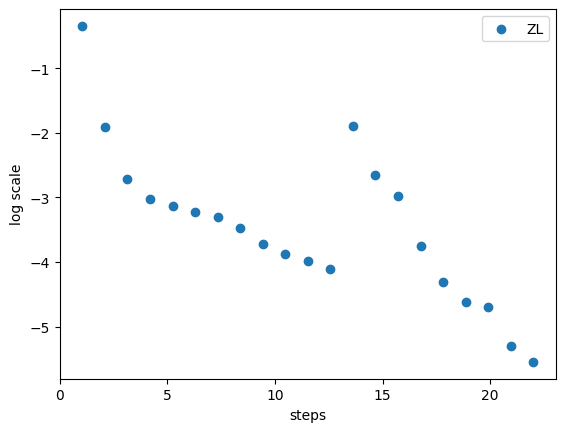

In [ ]:
print(history.keys())
key='ZL'

steps=np.linspace(0,int(N_STEPS/log_each)+2,int(N_STEPS/log_each)+2)
print(steps.shape,np.array(history[key]).shape)
plt.scatter(steps,np.log(history[key]),label=key)
plt.xlabel("steps")
plt.ylabel('log scale')
plt.legend()
plt.show()

# Comparación

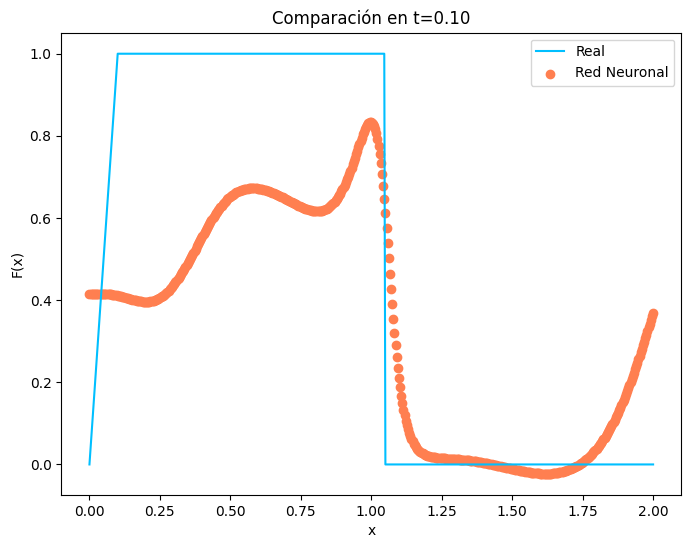

In [ ]:
#t=np.random.uniform(tmin,tmax)

def solucion(x,t):
  condition1 = x < 0
  condition2 = (0 <= x) & (x < t)
  condition3 = (t < x) & (x < t/2 + 1)
  condition4 = x > t/2 + 1

  result = np.where(condition1, 0,
            np.where(condition2, x / t,
            np.where(condition3, 1,
            np.where(condition4, 0, 0))))

  return result

t=0.1
# Crea un bucle para cada valor de tiempo

puntos=500

x = np.linspace(xmin,xmax,puntos)

  # Evalúa la función real y la salida de la red neuronal en la malla de puntos
t_array=np.zeros(puntos)
#Z_real=np.zeros(puntos)
for i in range (0,puntos):
    t_array[i]=t

tensor=np.column_stack((x,t_array))
Z_nn=model(tensor)

# Grafica las funciones

plt.figure(figsize=(8, 6))
plt.plot(x, solucion(x,t), label='Real',color='deepskyblue')
plt.scatter(x, Z_nn, label='Red Neuronal',color='coral')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title(f'Comparación en t={t:.2f}')
plt.legend()
plt.show()


# Metodos finitos

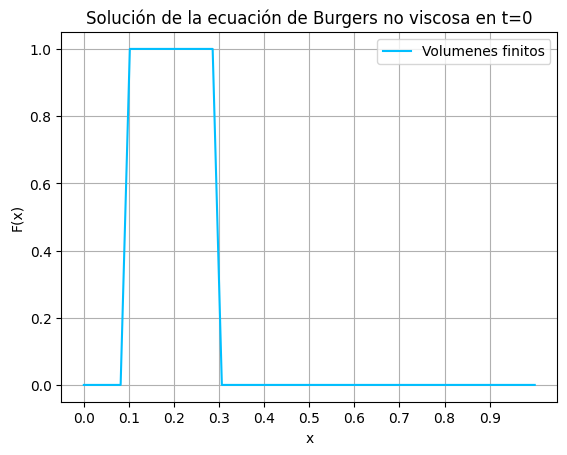

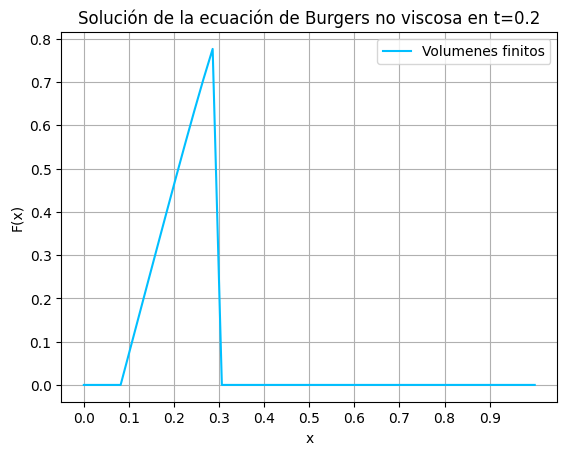

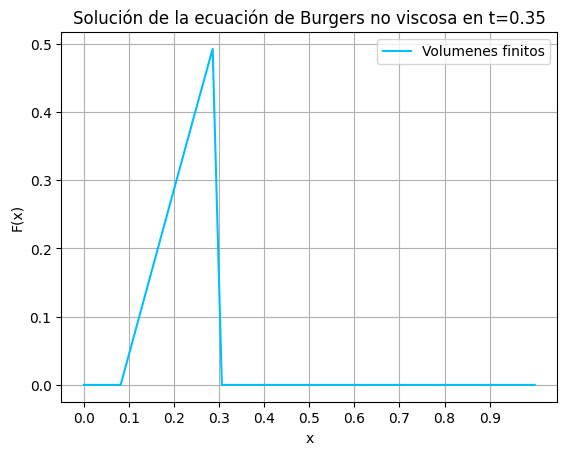

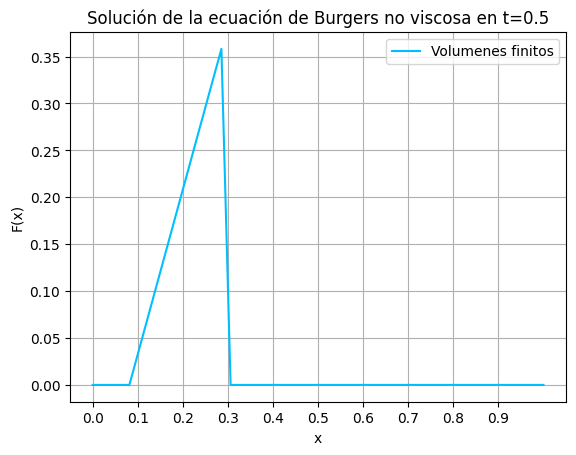

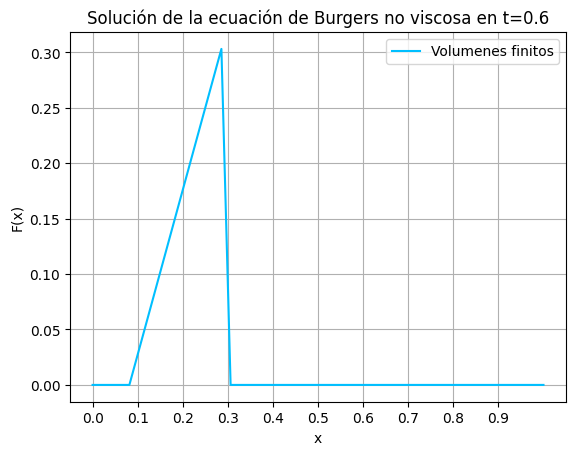

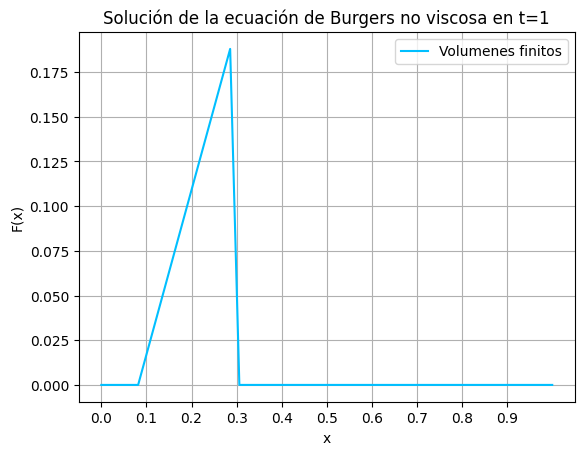

In [ ]:
## Parámetros
L = 1.0   # Longitud del dominio
nx = 50   # Número de nodos en el dominio espacial
nt = 1000  # Número de pasos de tiempo
dx = L / nx  # Tamaño del paso espacial
dt = 0.01   # Tamaño del paso de tiempo

# Inicialización de la condición inicial
x = np.linspace(0, L, nx)
u = np.zeros((nt, nx))
u[0, (x >= 0.1) & (x <= 0.3)] = 1  # Escalón entre 0.1 y 0.3 en t=0

# Iteración en el tiempo
for n in range(1, nt):
    for i in range(1, nx - 1):
        u[n, i] = u[n - 1, i] - u[n - 1, i] * dt / dx * (u[n - 1, i] - u[n - 1, i - 1])

    # Condiciones de contorno
    u[n, 0] = 0
    u[n, -1] = 0

t_array=np.zeros(nx)
# Función para graficar la solución en un instante de tiempo dado
def plot_solution_at_time(t):
    #Volumenes finitos
    t_index = int(t / dt)   # Índice de tiempo correspondiente al valor de t
    plt.plot(x, u[t_index, :], label='Volumenes finitos', color='deepskyblue')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.title(f'Solución de la ecuación de Burgers no viscosa en t={t}')
    plt.grid(True)

    for i in range (0,nx):
      t_array[i]=t

    tensor=np.column_stack((x,t_array))
   #Z_nn=model(tensor)

    # Grafica las funciones
    #plt.scatter(x, Z_nn, label='Red Neuronal',color='coral')
    plt.xlabel('x')
    plt.ylabel('F(x)')
    nuevos_valores_x = np.arange(0, 1, 0.1)  # Cambia los valores según lo necesites
    plt.xticks(nuevos_valores_x)
    plt.legend()
    plt.show()

# Graficar la solución en diferentes instantes de tiempo
plot_solution_at_time(0)  # Por ejemplo, para t=0.2
plot_solution_at_time(0.2)  # Para t=0.5
plot_solution_at_time(0.35)  # Para t=1.0
plot_solution_at_time(0.5)
plot_solution_at_time(0.6)
plot_solution_at_time(1)



# GIF


In [ ]:
t_values = np.linspace(0,1, 50)  # Valores de tiempo en los que quieres evaluar la función

# Crea un bucle para cada valor de tiempo
images = []
for t in t_values:
    # Define la malla de puntos (x, t)
    x = np.linspace(xmin, xmax, 50)
    X, T = np.meshgrid(x, [t])

    # Evalúa la función real y la salida de la red neuronal en la malla de puntos
    #t_array=np.zeros(50)
    #for i in range (0,50):
        #t_array[i]=t
    #tensor=np.column_stack((x,t_array))

    #Z_nn=model(tensor)

    t_index = int(t / (dt * nt))  # Índice de tiempo correspondiente al valor de t

    # Grafica las funciones
    plt.figure(figsize=(8, 6))
    #plt.plot(x, Z_real, label='Real',color='deepskyblue')
    plt.plot(x, u[t_index],label='volumenes finitos',color='deepskyblue')
    #plt.plot(x, Z_nn, label='Red Neuronal',color='coral')
    plt.xlabel('x')
    plt.ylabel('F(x)')
    plt.ylim(-1,1.5)
    plt.title(f'Comparación en t={t:.2f}')
    plt.legend(loc='upper left')

    # Guarda la imagen como un archivo temporal
    filename = f'comparison_t_{t:.2f}.png'
    plt.savefig(filename)
    images.append(imageio.imread(filename))
    plt.close()

# Combina las imágenes en un GIF
imageio.mimsave('burgers.gif', images)

# Otro caso

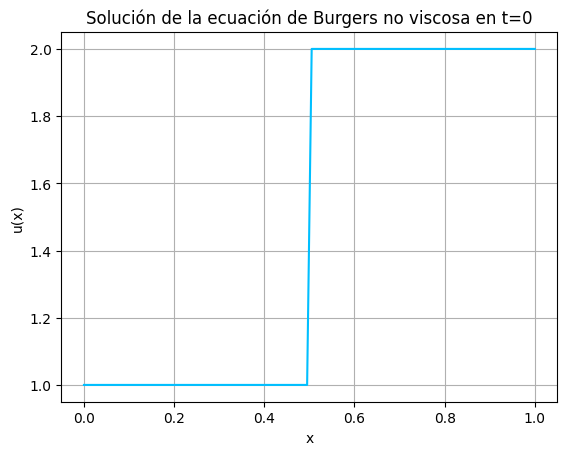

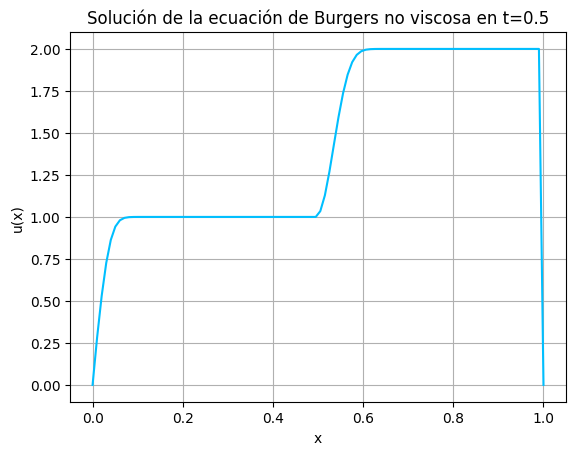

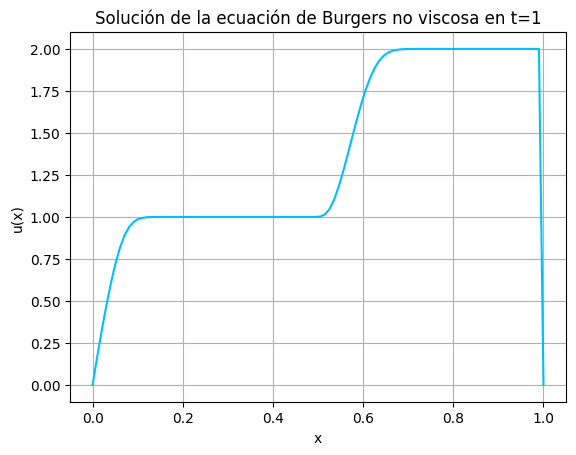

In [ ]:
# Parámetros
L = 1.0  # Longitud del dominio espacial
T = 1.0  # Tiempo total
Nx = 100  # Número de puntos de malla espacial
Nt = 1000  # Número de pasos de tiempo
dx = L / Nx  # Tamaño del paso espacial
dt = T / Nt  # Tamaño del paso temporal

# Discretización del espacio y tiempo
x = np.linspace(0, L, Nx)
t = np.linspace(0, T, Nt)

# Condiciones iniciales
u0 = np.where((0.5 <= x) & (x <= 1), 2, 1)

# Condiciones de contorno
#u0[0] = u0[-1] = 0

# Inicializar matriz para almacenar la solución
u = np.zeros((Nt, Nx))
u[0] = u0

# Método de volúmenes finitos
for n in range(1, Nt):
    for i in range(1, Nx - 1):
        u[n, i] = u[n - 1, i] - dt / dx * (u[n - 1, i] * (u[n - 1, i] - u[n - 1, i - 1]))

# Graficar la función en cada instante temporal
def plot_solution_at_time(t):
    #Volumenes finitos
    t_index = int(t / (dt * nt))  # Índice de tiempo correspondiente al valor de t
    plt.plot(x, u[t_index],label='volumenes finitos',color='deepskyblue')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.title(f'Solución de la ecuación de Burgers no viscosa en t={t}')
    plt.grid(True)
    plt.show()

plot_solution_at_time(0)
plot_solution_at_time(0.5)
plot_solution_at_time(1)

In [ ]:
def solucion(x,t):
  condition1 = x < 0
  condition2 = (0 <= x) & (x < t)
  condition3 = (t < x) & (x < t/2 + 1)
  condition4 = x > t/2 + 1

  result = np.where(condition1, 0,
            np.where(condition2, x / t,
            np.where(condition3, 1,
            np.where(condition4, 0, 0))))

  return result



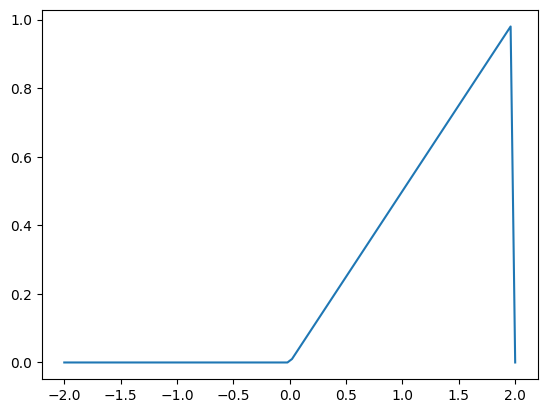

In [ ]:
x=np.linspace(xmin,xmax,100)
t=2
plt.plot(x,solucion(x,t))

